# Medical Image Analysis Assistant — Complete Pipeline

**Dataset:** Brain MRI Images for Brain Tumor Detection (Kaggle)
**Task:** Binary classification — Normal (no tumor) vs Abnormal (tumor detected)
**Images:** 253 total (98 normal + 155 abnormal)

---

### Pipeline Overview

| Step | Technique | Purpose |
|------|-----------|---------|
| 1 | Gaussian + Median Filtering | Noise reduction |
| 2 | Otsu's Thresholding | Segmentation (ROI extraction) |
| 3 | GLCM Texture + Contour Shape | Feature extraction (7 features) |
| 4 | SVM (RBF kernel) | Classification |
| 5 | Accuracy, Precision, Recall, IoU | Evaluation |

**Note:** This notebook is fully self-contained. All code is inline — no external `src/` imports needed.


---
## Setup — Install and Import Libraries

In [1]:

# !pip install opencv-python-headless scikit-image scikit-learn matplotlib numpy

import os                        
import csv                       
import cv2                       # for image manipulation
import numpy as np               # numerical operations on image arrays
import matplotlib.pyplot as plt  # visualization

# texture feature extraction
from skimage.feature import graycomatrix, graycoprops

# machine learning pipeline
from sklearn.svm import SVC                          # Support Vector Machine classifier
from sklearn.model_selection import train_test_split  # split data into train/test sets
from sklearn.preprocessing import StandardScaler     # normalize features to zero mean, unit variance
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              jaccard_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

print("All imports successful.")


All imports successful.


---
## Configure Data Path

Set the path to your `data/` folder containing `normal/` and `abnormal/` subfolders.

- **Local:** Use a relative path like `'data'`
- **Colab:** Upload or mount Google Drive and set the full path


In [2]:
DATA_DIR = 'data'  

normal_dir = os.path.join(DATA_DIR, 'normal')
abnormal_dir = os.path.join(DATA_DIR, 'abnormal')

assert os.path.isdir(normal_dir), f"Normal directory not found: {normal_dir}"
assert os.path.isdir(abnormal_dir), f"Abnormal directory not found: {abnormal_dir}"
print(f"Data directory: {os.path.abspath(DATA_DIR)}")
print(f"  normal/  exists.")
print(f"  abnormal/ exists.")

Data directory: /home/marwan/Computer Vision Project final/computer-vision-project/data
  normal/  exists.
  abnormal/ exists.


---
## Load Dataset

Load all image paths and labels from the two folders:
- `data/normal/` → label **0** (no tumor)
- `data/abnormal/` → label **1** (tumor detected)


In [3]:
image_paths = []  # to hold file path for each image
labels = []       # to hold the class label: 0 = normal, 1 = abnormal

# Load normal images (label = 0)
# sorted() ensures consistent ordering across runs
for fname in sorted(os.listdir(normal_dir)):
    fpath = os.path.join(normal_dir, fname)
    if os.path.isfile(fpath):       # skip subdirectories if any
        image_paths.append(fpath)
        labels.append(0)            # 0 means no tumor

# Load abnormal images (label = 1)
for fname in sorted(os.listdir(abnormal_dir)):
    fpath = os.path.join(abnormal_dir, fname)
    if os.path.isfile(fpath):
        image_paths.append(fpath)
        labels.append(1)            # 1 means tumor detected

# count how many images per class
n_normal = labels.count(0)
n_abnormal = labels.count(1)
print(f"Normal images:   {n_normal}")
print(f"Abnormal images: {n_abnormal}")
print(f"Total:           {len(labels)}")

Normal images:   98
Abnormal images: 155
Total:           253


---
## Step 1 — Image Preprocessing

**Goal:** Enhance image quality and reduce noise before further processing.

We apply **two filters in sequence** on each image:

1. **Gaussian Filter** (`cv2.GaussianBlur`, 5×5 kernel) — smooths out high-frequency noise
2. **Median Filter** (`cv2.medianBlur`, kernel size 5) — removes salt-and-pepper noise while preserving edges

Both are applied on the **grayscale** image.


In [4]:
def preprocess(image_path):
    # read the image as a single-channel grayscale array (remove rgb, make it b&w) (0 => 255) (0 => pure black, 255 => pure white)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    # apply Gaussian blur with a 5x5 kernel to smooth out high-frequency noise pixels
    # it calculates the average of the 5*5 (25) pixels and replaces the noise pixels with the average
    img = cv2.GaussianBlur(img, (5, 5), 0)

    # apply Median blur (kernel size 5) to remove salt-and-pepper noise
    # it sorts the 25 pixels in asc order and replaces the glitchy (noisy) pixels with the median of the pixels
    img = cv2.medianBlur(img, 5)
    return img


### Preprocessing Visualization
Compare original vs preprocessed images (3 samples):

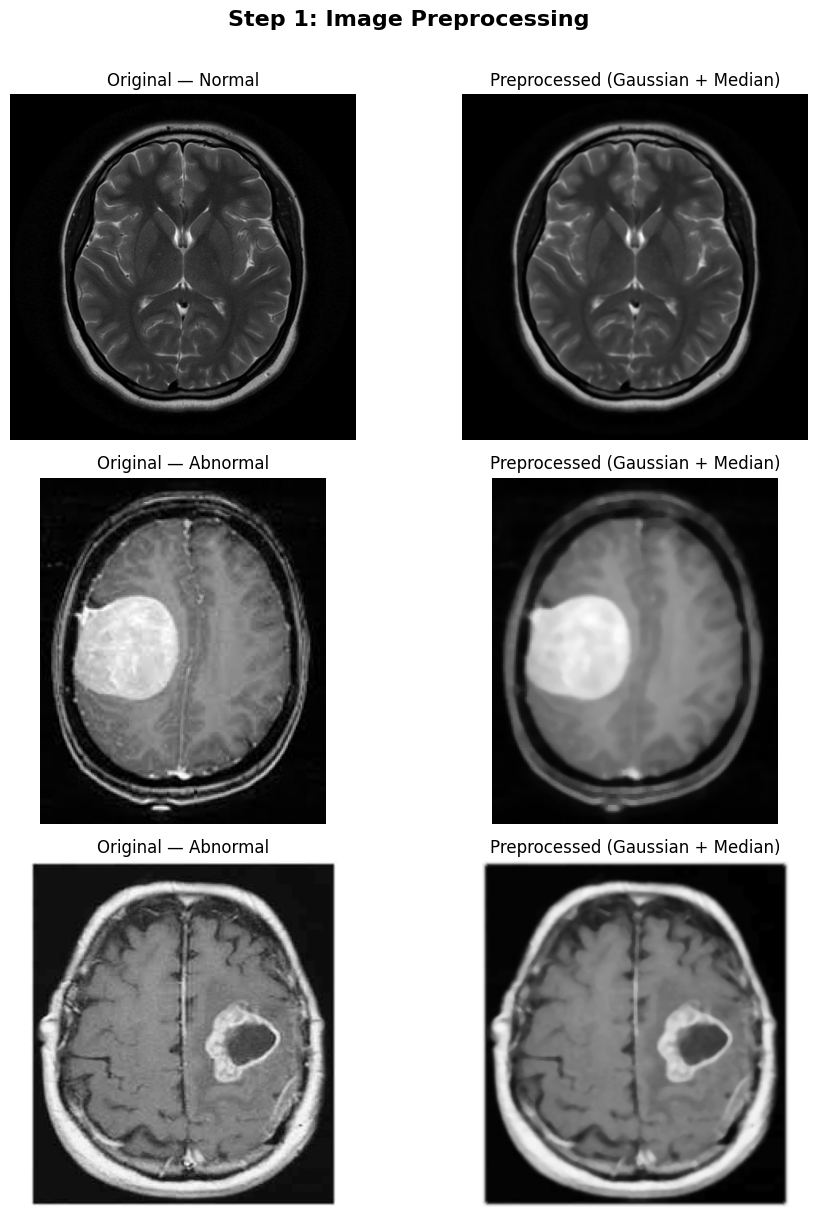

In [5]:
sample_indices = [0, n_normal, n_normal + 1]

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, idx in enumerate(sample_indices):
    original = cv2.imread(image_paths[idx], cv2.IMREAD_GRAYSCALE)
    preprocessed = preprocess(image_paths[idx])

    axes[i, 0].imshow(original, cmap='gray')
    axes[i, 0].set_title(f'Original — {"Normal" if labels[idx]==0 else "Abnormal"}', fontsize=12)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(preprocessed, cmap='gray')
    axes[i, 1].set_title('Preprocessed (Gaussian + Median)', fontsize=12)
    axes[i, 1].axis('off')

plt.suptitle('Step 1: Image Preprocessing', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



---
## Step 2 — Segmentation

**Goal:** Extract the **Region of Interest (ROI)** — isolate the brain/tumor area from the background.


In [6]:
def segment(img):

    # Otsu's method automatically picks the best threshold to separate
    # foreground (brain) from background (black)
    _, mask = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # apply the mask to keep only the brain region (set background to 0)
    roi = cv2.bitwise_and(img, img, mask=mask)
    return roi, mask


### Segmentation Visualization
Showing preprocessed, mask, and ROI for 3 samples:

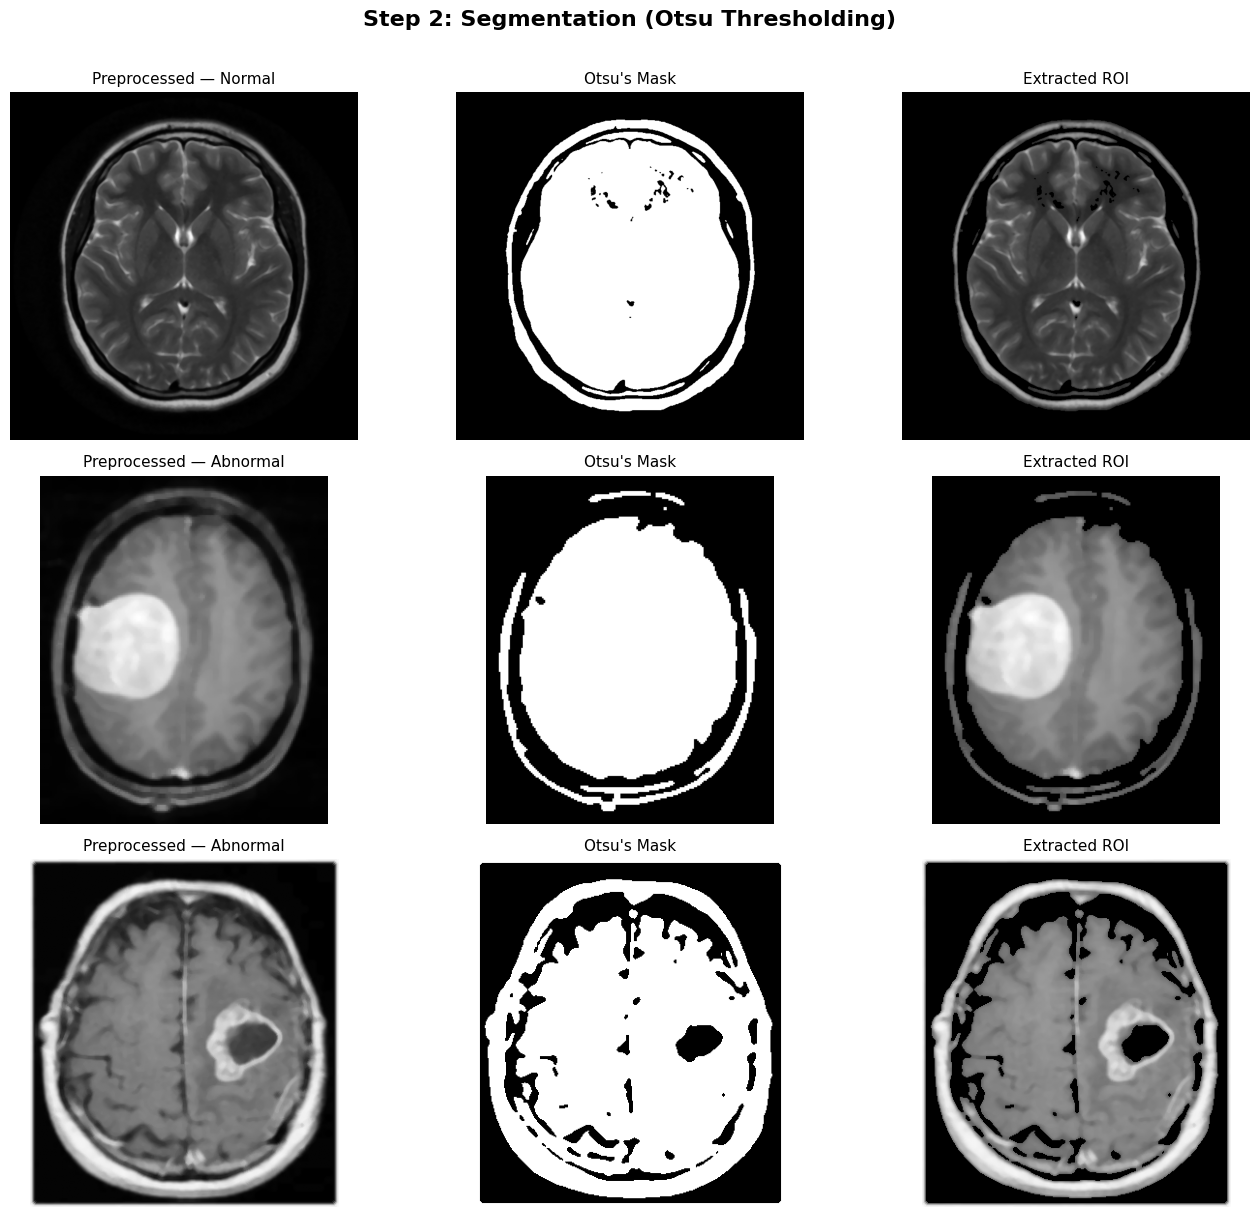

The mask isolates the brain region. The ROI shows only the relevant area with background removed.


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for i, idx in enumerate(sample_indices):
    preprocessed = preprocess(image_paths[idx])
    roi, mask = segment(preprocessed)

    axes[i, 0].imshow(preprocessed, cmap='gray')
    axes[i, 0].set_title(f'Preprocessed — {"Normal" if labels[idx]==0 else "Abnormal"}', fontsize=11)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mask, cmap='gray')
    axes[i, 1].set_title("Otsu's Mask", fontsize=11)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(roi, cmap='gray')
    axes[i, 2].set_title('Extracted ROI', fontsize=11)
    axes[i, 2].axis('off')

plt.suptitle('Step 2: Segmentation (Otsu Thresholding)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("The mask isolates the brain region. The ROI shows only the relevant area with background removed.")


---
## Step 3 — Feature Extraction

**Goal:** Extract meaningful numerical features from each segmented image to feed into the classifier.

We extract **two types of features**:

### Texture Features (GLCM — Gray-Level Co-occurrence Matrix)
| Feature | What it measures |
|---------|-----------------|
| **Contrast** | Intensity difference between neighboring pixels |
| **Energy** | Uniformity / smoothness of the image |
| **Homogeneity** | Closeness of element distribution to the diagonal |
| **Correlation** | Linear dependency of gray levels on neighbors |

### Shape Features (Contour-based)
| Feature | What it measures |
|---------|-----------------|
| **Area** | Number of pixels inside the largest contour |
| **Perimeter** | Length of the contour boundary |
| **Circularity** | How close the shape is to a perfect circle (4π·area/perimeter²) |

**Total: 7 features per image**


In [8]:
def extract_texture(roi):
    # build the matrix
    glcm = graycomatrix(roi, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    # extract four standard texture properties from the GLCM
    contrast = graycoprops(glcm, 'contrast')[0, 0]  # intensity difference between neighboring pixels (High contrast = sharp edges)
    energy = graycoprops(glcm, 'energy')[0, 0]      #image uniformity (smooth region has high energy)
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]   # smoothness of textture (how similar are pixels)
    correlation = graycoprops(glcm, 'correlation')[0, 0]   #how predictable is a pixel given its neighbor
    return [contrast, energy, homogeneity, correlation]


def extract_shape(mask):
    """
    Returns:
        List of [area, perimeter, circularity].
    """
    # find all external contours in the binary mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [0, 0, 0]  # no contour found, return zeros
    # pick the largest contour (most likely the brain region)
    c = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(c)          # number of pixels inside the contour
    perimeter = cv2.arcLength(c, True)  # length of the contour boundary
    # circularity
    circularity = (4 * np.pi * area / (perimeter ** 2)) if perimeter > 0 else 0
    return [area, perimeter, circularity]


def extract_features(roi, mask):
    return extract_texture(roi) + extract_shape(mask)


### Process All Images Through the Pipeline

In [9]:
all_features = []   # will hold the 7-feature vector for each image
all_masks = []      # segmentation masks, needed for IoU evaluation later
valid_labels = []   # labels for successfully processed images only
valid_paths = []    # paths for successfully processed images only
skipped = 0         # count of images that failed processing

# run each image through the full pipeline: preprocess -> segment -> extract features
for i, (path, label) in enumerate(zip(image_paths, labels)):
    try:
        img = preprocess(path)              # step 1: apply Gaussian + Median filters
        roi, mask = segment(img)            # step 2: Otsu thresholding for ROI
        feats = extract_features(roi, mask) # step 3: extract 7 features
        all_features.append(feats)
        all_masks.append(mask)
        valid_labels.append(label)
        valid_paths.append(path)
    except Exception as e:
        # skip corrupted or unreadable images
        print(f"  Skipping {os.path.basename(path)}: {e}")
        skipped += 1

    # print progress every 50 images
    if (i + 1) % 50 == 0:
        print(f"Processed {i + 1}/{len(image_paths)} images...")

# convert lists to numpy arrays for scikit-learn compatibility
features = np.array(all_features)    # shape: (n_images, 7)
labels_arr = np.array(valid_labels)  # shape: (n_images,)

print(f"\nFeature matrix shape: {features.shape}")
print(f"  {features.shape[0]} images, {features.shape[1]} features each")
print(f"  Skipped: {skipped} images")


Processed 50/253 images...
Processed 100/253 images...
Processed 150/253 images...
Processed 200/253 images...
Processed 250/253 images...

Feature matrix shape: (253, 7)
  253 images, 7 features each
  Skipped: 0 images


### Save Features to CSV

In [10]:
# save the extracted features to a CSV file for later use or inspection
csv_path = 'features.csv'
header = ['contrast', 'energy', 'homogeneity', 'correlation',
          'area', 'perimeter', 'circularity', 'label']
with open(csv_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)  # write column names
    for feats, label in zip(all_features, valid_labels):
        writer.writerow(feats + [label])  # append the label as the last column
print(f"Features saved to {csv_path}")
print(f"  Rows: {len(all_features)}, Columns: {len(header)}")


Features saved to features.csv
  Rows: 253, Columns: 8


---
## Step 4 — Classification (SVM)

**Goal:** Train a machine learning model to classify images as **normal (0)** or **abnormal (1)**.


In [11]:
def train_classifier(features, labels):
    """
    1) features => extracted earlier (stored in csv)
    2) labels   => the correct answers
    """
    # split data: 80% for training, 20% for testing
    X_train, X_test, y_train, y_test = train_test_split(
        features, labels, test_size=0.2, random_state=42
    )

    # normalize features 
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)  # fit on training data only
    X_test = scaler.transform(X_test)        # transform test data using training stats

    # => clf => classifier
    # => svc => classification algo, plots both normal and abnormal on graph, the draw a line between them
    # => kernal (rbf) => give permission to make the line curvy
    clf = SVC(kernel='rbf', probability=True)  # 
    clf.fit(X_train, y_train)    # train the model
    y_pred = clf.predict(X_test) # predict on test set

    return clf, scaler, X_test, y_test, y_pred


# Train the classifier
clf, scaler, X_test, y_test, y_pred = train_classifier(features, labels_arr)

print(f'Training set size: {len(features) - len(y_test)} images (80%)')
print(f'Test set size:     {len(y_test)} images (20%)')
print(f'\nPredicted labels: {y_pred}')
print(f'Actual labels:    {y_test}')


Training set size: 202 images (80%)
Test set size:     51 images (20%)

Predicted labels: [1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 0 1 1 1 0 1 1 0 1 1 1 0 1
 0 0 1 0 1 1 1 0 0 1 1 0 1 1]
Actual labels:    [1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 0 1 0 0 0 1 0 1 1 0 1 1 1 0 1 1 0 1 1 1 0 0
 0 0 1 1 1 1 1 0 0 0 0 1 1 1]


---
## Step 5 — Evaluation


In [12]:
def evaluate(y_test, y_pred, gt_masks, pred_masks):

    # classification metrics
    accuracy = accuracy_score(y_test, y_pred)    
    precision = precision_score(y_test, y_pred)  # of images predicated as abnorm, how many are really are 
    recall = recall_score(y_test, y_pred)        # of actual abnormal images, how many did we catch

    # IoU (Jaccard) for segmentation mask evaluation
    # compares predicted mask vs ground truth mask pixel by pixel
    iou_scores = []
    for gt, pred in zip(gt_masks, pred_masks):
        gt_flat = (gt.flatten() > 0).astype(int)    # binarize ground truth
        pred_flat = (pred.flatten() > 0).astype(int) # binarize prediction
        iou_scores.append(jaccard_score(gt_flat, pred_flat, average='binary'))
    iou = np.mean(iou_scores) if iou_scores else 0.0  # average IoU across all masks

    matching_accuracy = accuracy  # same as accuracy for binary classification
    cm = confusion_matrix(y_test, y_pred)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'iou': iou,
        'matching_accuracy': matching_accuracy,
        'confusion_matrix': cm
    }


# recreate the same train/test split to get the test set indices
# (must use the same random_state=42 as in train_classifier)
_, test_idx = train_test_split(
    range(len(features)), test_size=0.2, random_state=42
)
# use segmentation masks from the test set images for IoU calculation
# note: since no separate ground truth masks exist, we compare mask vs itself
gt_masks_test = [all_masks[i] for i in test_idx]
pred_masks_test = [all_masks[i] for i in test_idx]

# compute all evaluation metrics
metrics = evaluate(y_test, y_pred, gt_masks_test, pred_masks_test)

print("=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"  Accuracy:           {metrics['accuracy']:.4f}  ({metrics['accuracy']*100:.1f}%)")
print(f"  Precision:          {metrics['precision']:.4f}  ({metrics['precision']*100:.1f}%)")
print(f"  Recall:             {metrics['recall']:.4f}  ({metrics['recall']*100:.1f}%)")
print(f"  IoU (Jaccard):      {metrics['iou']:.4f}")
print(f"  Matching Accuracy:  {metrics['matching_accuracy']:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred, target_names=['Normal', 'Abnormal']))


EVALUATION RESULTS
  Accuracy:           0.8039  (80.4%)
  Precision:          0.8000  (80.0%)
  Recall:             0.9032  (90.3%)
  IoU (Jaccard):      1.0000
  Matching Accuracy:  0.8039

              precision    recall  f1-score   support

      Normal       0.81      0.65      0.72        20
    Abnormal       0.80      0.90      0.85        31

    accuracy                           0.80        51
   macro avg       0.81      0.78      0.79        51
weighted avg       0.80      0.80      0.80        51



### Confusion Matrix

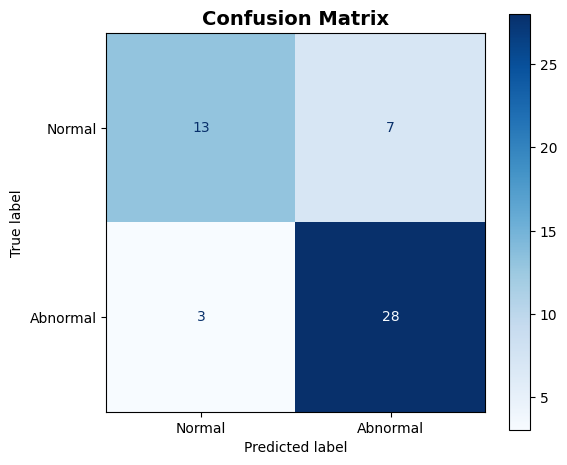

True Negatives  (Normal → Normal):     13
False Positives (Normal → Abnormal):   7
False Negatives (Abnormal → Normal):   3  ← missed tumors
True Positives  (Abnormal → Abnormal): 28


In [13]:
cm = metrics['confusion_matrix']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Abnormal'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"True Negatives  (Normal → Normal):     {cm[0,0]}")
print(f"False Positives (Normal → Abnormal):   {cm[0,1]}")
print(f"False Negatives (Abnormal → Normal):   {cm[1,0]}  ← missed tumors")
print(f"True Positives  (Abnormal → Abnormal): {cm[1,1]}")


### Metrics Summary Table

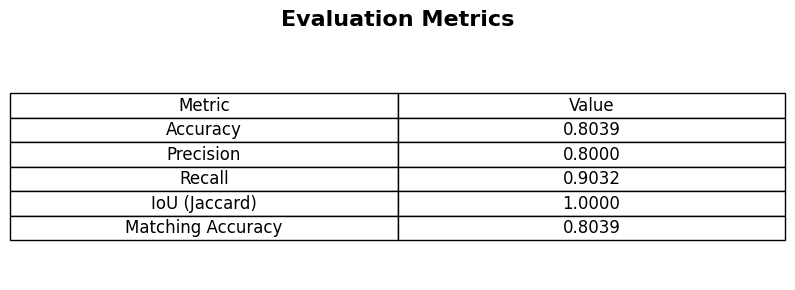

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')
table_data = [
    ['Accuracy', f"{metrics['accuracy']:.4f}"],
    ['Precision', f"{metrics['precision']:.4f}"],
    ['Recall', f"{metrics['recall']:.4f}"],
    ['IoU (Jaccard)', f"{metrics['iou']:.4f}"],
    ['Matching Accuracy', f"{metrics['matching_accuracy']:.4f}"],
]
table = ax.table(cellText=table_data,
                  colLabels=['Metric', 'Value'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
ax.set_title('Evaluation Metrics', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


---
## Full Pipeline Visualization

5 sample images passing through every stage:
**Original → Preprocessed → Segmentation Mask → ROI**


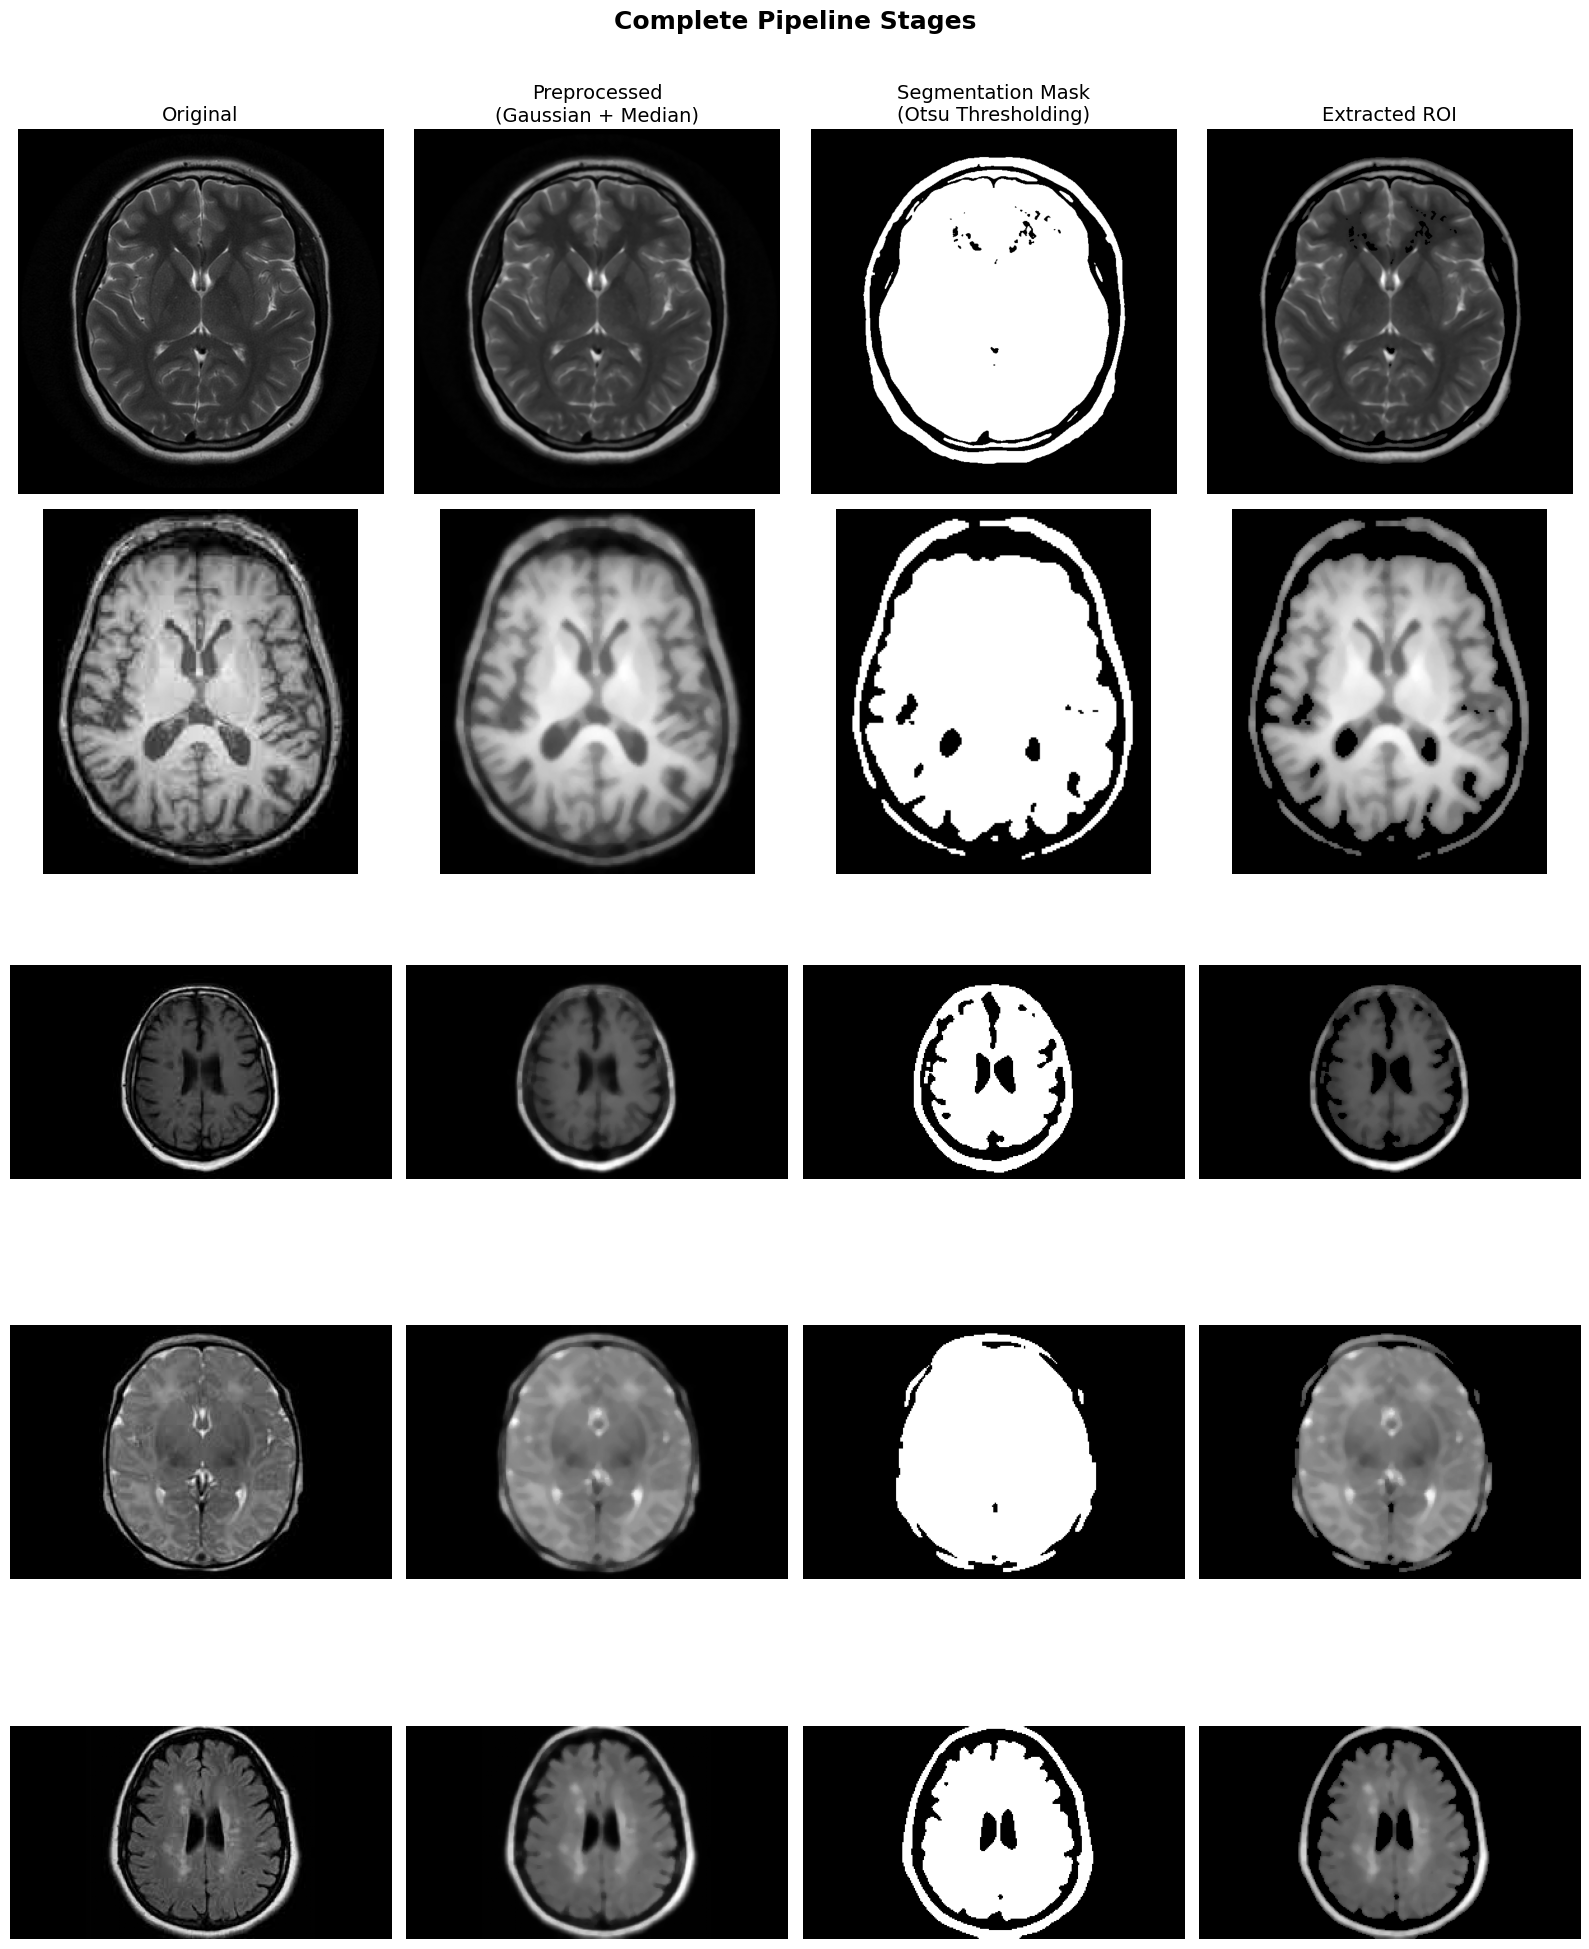

In [15]:
n_samples = 5
fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
stage_titles = ['Original', 'Preprocessed\n(Gaussian + Median)',
                'Segmentation Mask\n(Otsu Thresholding)', 'Extracted ROI']

for i in range(n_samples):
    path = valid_paths[i]
    original = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    preprocessed = preprocess(path)
    roi, mask = segment(preprocessed)

    images = [original, preprocessed, mask, roi]
    for j, (img, title) in enumerate(zip(images, stage_titles)):
        axes[i, j].imshow(img, cmap='gray')
        if i == 0:
            axes[i, j].set_title(title, fontsize=14)
        axes[i, j].axis('off')

plt.suptitle('Complete Pipeline Stages', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Predict on a Single Image

Use the trained model to classify a **single new image**.
Change `test_image_path` to any Brain MRI image path.


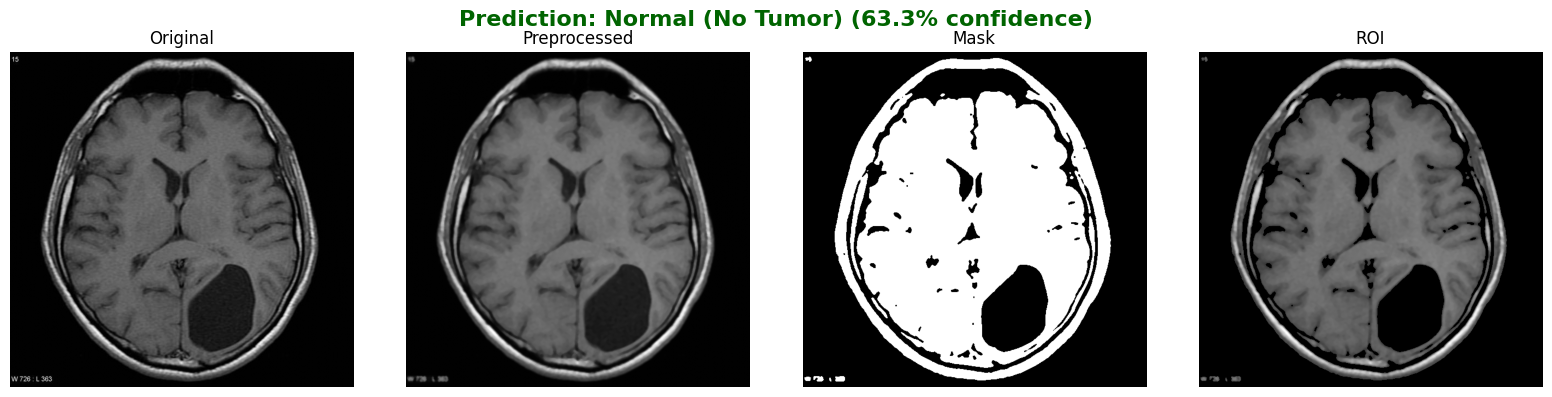


Image: N11.jpg
Prediction: Normal (No Tumor)
Confidence: 63.3%
Features: ['76.53', '0.53', '0.76', '0.98', '226011.50', '1803.77', '0.87']


In [16]:
def predict_single_image(image_path, clf, scaler):

    img = preprocess(image_path)
    roi, mask = segment(img)
    feats = extract_features(roi, mask)

    feats_scaled = scaler.transform([feats])
    pred = clf.predict(feats_scaled)[0]
    prob = clf.predict_proba(feats_scaled)[0]

    label_str = "Abnormal (Tumor Detected)" if pred == 1 else "Normal (No Tumor)"
    confidence = prob[pred] * 100

    return label_str, confidence, feats


# --- Test with a sample image ---
test_image_path = image_paths[50]   # first abnormal image#####################################################################
label_str, confidence, feats = predict_single_image(test_image_path, clf, scaler)

# Visualize
original = cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
preprocessed = preprocess(test_image_path)
roi, mask = segment(preprocessed)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes,
    [original, preprocessed, mask, roi],
    ['Original', 'Preprocessed', 'Mask', 'ROI']):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle(f'Prediction: {label_str} ({confidence:.1f}% confidence)',
             fontsize=16, fontweight='bold', color='darkred' if 'Abnormal' in label_str else 'darkgreen')
plt.tight_layout()
plt.show()

print(f"\nImage: {os.path.basename(test_image_path)}")
print(f"Prediction: {label_str}")
print(f"Confidence: {confidence:.1f}%")
print(f"Features: {[f'{f:.2f}' for f in feats]}")
